# Adding a time series encoder

In an attempt to equalize the influence of the time series (dim $\approx 1000$) and the corresponding parameters (dim $\approx 4-400$), we would like to compress the time series. Here we implement a 1d-CNN network. This network can handle variable time sequences, because of the average pooling layer, that returns a single average value for each channel, regardless of sequence length. 

In [ ]:
import sys
sys.path.append('..')

from src.simulator import Model, BurstSimulator
from src.flow_matching.distributions import Prior, Posterior
from src.flow_matching.probability_path import GuidedLinearProbabilityPath
from src.flow_matching.training import GuidedConditionalFlowMatchingTrainer
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPGuidedVectorField, FRBLightCurveCNN
from src.helpers import record_every

from corner import corner
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.flow_matching.plotting import plot_loss, plot_snapshots
from src.flow_matching.helpers import choose_device

# choose device
device = choose_device()
print("CURRENT DEVICE: ", device)

CURRENT DEVICE:  cuda


In [3]:
path = GuidedLinearProbabilityPath(
    p_simple=Prior(),
    p_data=Posterior()
)

latent_dim = 128
time_seq_encoder = FRBLightCurveCNN(latent_dim=latent_dim)

vector_field = MLPGuidedVectorField(dim=2, hiddens=[64, 64, 32, 16], time_dim=latent_dim, time_seq_encoder=time_seq_encoder)

trainer = GuidedConditionalFlowMatchingTrainer(path, vector_field)
losses = trainer.train(2000, device, 5e-4, save_checkpoint=False, batch_size=256)

Training model with size: 0.635 MiB


  0%|          | 0/2000 [00:00<?, ?it/s]/home/ninameulen/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,
/home/ninameulen/.local/lib/python3.10/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 1999, loss: 0.050, lr: 1.60e-05: 100%|██████████| 2000/2000 [08:55<00:00,  3.73it/s]


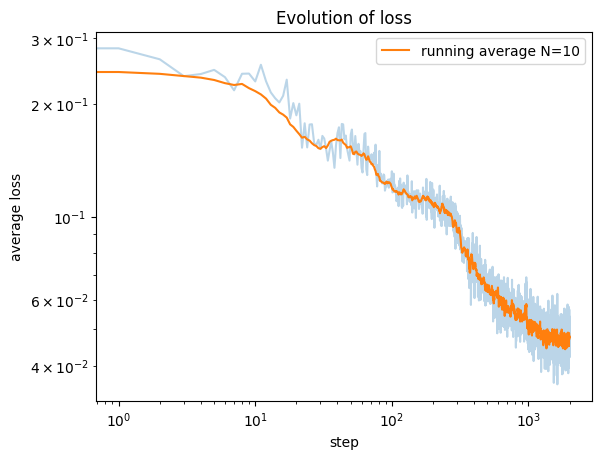

In [4]:
plot_loss(losses, window_size=10, show=False)

100%|██████████| 99/99 [00:02<00:00, 35.29it/s] 


tensor([[0.0919, 0.9710],
        [0.1189, 0.9081],
        [0.2971, 0.7616],
        ...,
        [0.2688, 0.7619],
        [0.1066, 0.7530],
        [0.1887, 0.7039]], device='cuda:0')

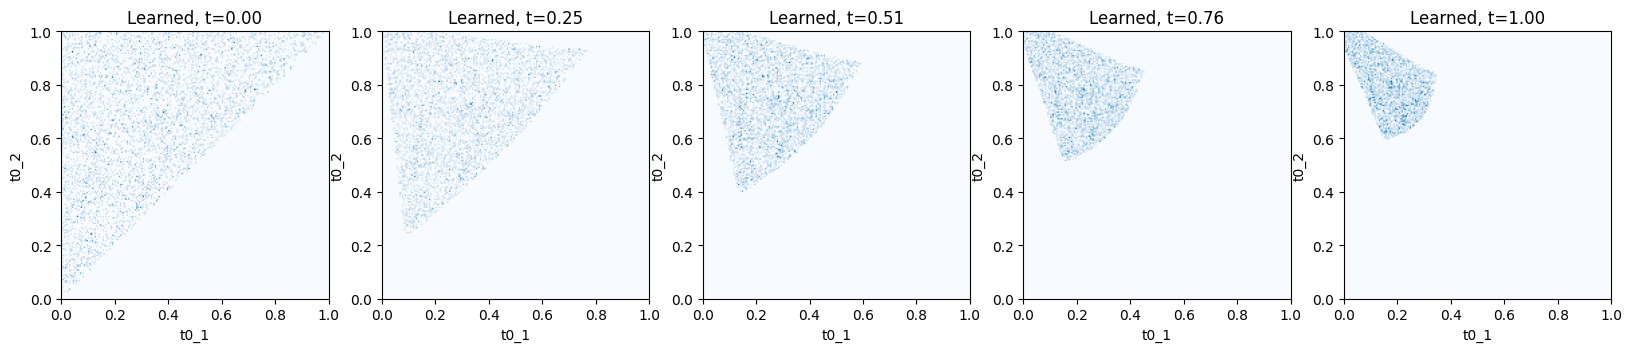

In [ ]:
# --------------------------------------------- #
#   Plot Marginal Path of Learned Vector Field  #
# --------------------------------------------- #

# fixed model parameters (NOTE: Should be same as used during training in Posterior)
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 25.0
rise = 0.03
skew = 5
ybkg = 5.0
true_t0 = [0.2, 0.8] # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)

# generate simulated data for one burst
burstparams = {
    't0'   : true_t0, 
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

# generate one instance of simulated data
model = Model(time=time, ncomp=N, burstparams=burstparams, ybkg=ybkg)
simulator = BurstSimulator(model)
x_counts = simulator.simulate_burst() 

# NOTE: if I make num_samples too high (>= 10000), kernel crashes :(, I think because of the array I reserve to save the simulations
num_samples = 5000  # number of prior samples to transform 
num_marginals = 5   # number of snapshots

# TODO: maybe do this in batches
# use same data for all prior samples
simulation_time_resolution = 1000
simulations = torch.tensor(x_counts, device=device, dtype=torch.float).repeat(num_samples, 1)

# Initialize ODE solver
solver = EulerODESolver(vector_field)
ts = torch.linspace(0, 1, 100).to(device)

# simulate ODE starting from x0   # TODO: should simulation be from the one used in training? 
x0 = path.p_simple.sample(num_samples).to(device)
xts = solver.solve_with_trajectory(x0, ts.view(1, -1, 1).expand(num_samples,-1,1), y=simulations)

# only save num_marginals snapshots 
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

# plot snapshots of marginal path
final_snapshot = plot_snapshots(xts, ts, record_every_idxs, num_marginals, show=False)

/tmp/ipykernel_2889/2625643727.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


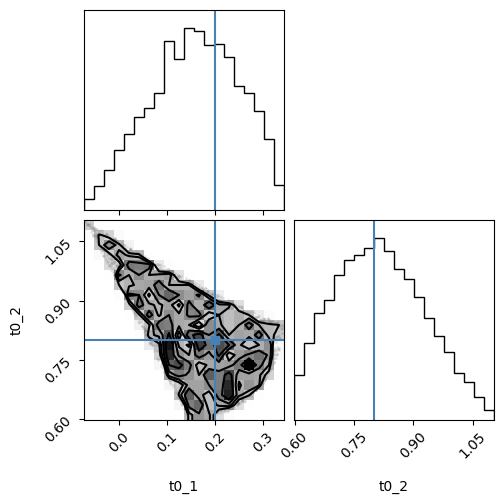

In [7]:
fig = corner(final_snapshot.cpu().numpy(), labels=["t0_1", "t0_2"], truths=np.array(true_t0))
fig.show()

# NOTE: Longer seq length, same time res = good, same length, higher time res = bad